# Métodos Avanzados: medidas de similaridad y distancia

### Ejercicio N°1

Para cada uno de los siguientes pares de cadenas, calcule la similaridad de Jaro y Jaro-Winkler y la distancia de Levenshtein. Realice primero el cálculo en forma manual y luego verifique los resultados obtenidos utilizando herramientas de la librería `rapidfuzz`.

| **cadena 1** | **cadena 2** |
| --- | --- |
| Mariana | Merianna |
| Della Ceca | Dellacecca |
| Córdoba 2568 | Cordoba 2478 |
| San Martín | AsnMartín |

Analice por qué Jaro-Winkler da mayor similaridad que Jaro en ciertos pares y no en otros.

In [1]:
from rapidfuzz.distance import Jaro, JaroWinkler, Levenshtein

#### MARIANA vs. MERIANNA

- $s_1$: `MARIANA`

- $s_2$: `MERIANNA`

Las longitudes de estas cadenas son $|s_1| = 7$ y $|s_2| = 8$.

**Paso 1: determinar el umbral de coincidencia**

Dos caracteres se consideran coincidentes si son iguales y la distancia entre sus posiciones no supera:

$$\big[\frac{max(|s_1|, |s_2|)}{2}\big] - 1 = 4 - 1 = 3$$

**Paso 2: identificar los caracteres coincidentes y calcular $m$**

Alineamos las cadenas posición a posición para facilitar la visualización:

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Pos.</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>1</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">M</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">I</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;"></td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>2</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">M</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">I</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
    </tr>
  </tbody>
</table>

Recorremos $s_1$ caracter por caracter y buscamos, dentro del umbral de 3 posiciones, si ese carácter aparece en $s_2$ (sin reutilizar caracteres ya emparejados):

- M (pos. 1): coincide con la M en pos. 1 de $s_2$ (distancia 0).
- A (pos. 2): coincide con la A en pos. 5 de $s_2$ (distancia = 3).
- R (pos. 3): coincide con la R en pos. 3 de $s_2$ (distancia 0).
- I (pos. 4): coincide con la I en pos. 4 de $s_2$ (distancia 0).
- A (pos. 5): coincide con la A en pos. 8 de $s_2$ (distancia = 3).
- N (pos. 6): coincide con la N en pos. 6 de $s_2$ (distancia 0).
- A (pos. 7): no hay ninguna A restante en $s_2$.

Por lo tanto, $m = 6$.

**Paso 3: identificar las transposiciones y calcular $t$**

Para calcular las transposiciones, construimos una nueva tabla listando únicamente los caracteres coincidentes. Tanto para $s_1$ como para $s_2$ los tomamos en el orden en que aparecen en las cadenas originales:

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Par</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_1$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">M</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">I</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">N</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_2$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">M</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">I</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">A</td>
    </tr>
  </tbody>
</table>

El primer par coincide en posición. En los últimos cinco, en cambio, el carácter de $s_1$ y el de $s_2$ son distintos. Estos son los 5 caracteres transpuestos (resaltados en rojo). Según la definición de Jaro, $t$ es la mitad de ese conteo:

$$t = \frac{5}{2} = 2.5 \approx 2$$

**Paso 4: calcular la similaridad de Jaro**

Con $m = 6$, $|s_1| = 7$, $|s_2| = 8$ y $t = 2$:

$$sim_J = \frac{1}{3}\big(\frac{6}{7} + \frac{6}{8} + \frac{6 - 2}{6}\big) = 0.7579$$

**Cálculo de la similaridad de Jaro-Winkler**

La única coincidencia al inicio de ambas cadenas está dada por la letra `M`. Con el valor estándar $p = 0.1$:

$$sim_{JW} = 0.7579 + 1 \cdot 0.1 \cdot (1 - 0.7579) = 0.7821$$

**Distancia de Levenshtein**

La secuencia mínima de operaciones para transformar `MARIANA` en `MERIANNA` es:
- Sustituir `A` → `E` en la posición 2.
- Insertar `N` antes de la última `A`.

Por lo tanto: $d_L = 2$.

**Verificación de los resultados obtenidos:**

In [2]:
# Similitud de Jaro (redondeada a 4 decimales)
sim_j = round(Jaro.similarity('MARIANA', 'MERIANNA'), 4)
print(f'Jaro:          {sim_j}')

# Similitud de Jaro-Winkler
sim_jw = round(JaroWinkler.similarity('MARIANA', 'MERIANNA'), 4)
print(f'Jaro-Winkler:  {sim_jw}')

# Distancia de Levenshtein
dist_lev = Levenshtein.distance('MARIANA', 'MERIANNA')
print(f'Levenshtein:   {dist_lev}')

Jaro:          0.7579
Jaro-Winkler:  0.7821
Levenshtein:   2


#### DELLA CECA vs. DELLACECCA

- $s_1$: `DELLA CECA`

- $s_2$: `DELLACECCA`

Las longitudes de estas cadenas son $|s_1| = 10$ y $|s_2| = 10$.

**Paso 1: determinar el umbral de coincidencia**

$$\big[\frac{max(|s_1|, |s_2|)}{2}\big] - 1 = 5 - 1 = 4$$

**Paso 2: identificar los caracteres coincidentes y calcular $m$**

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Pos.</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">9</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">10</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>1</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">D</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">L</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">L</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">_</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>2</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">D</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">L</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">L</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
    </tr>
  </tbody>
</table>

- D (pos. 1): coincide con D en pos. 1 (distancia 0).
- E (pos. 2): coincide con E en pos. 2 (distancia 0).
- L (pos. 3): coincide con L en pos. 3 (distancia 0).
- L (pos. 4): coincide con L en pos. 4 (distancia 0).
- A (pos. 5): coincide con A en pos. 5 (distancia 0).
- _ (pos. 6): no hay espacio en $s_2$.
- C (pos. 7): coincide con C en pos. 6 de $s_2$ (distancia = 1).
- E (pos. 8): coincide con E en pos. 7 de $s_2$ (distancia = 1).
- C (pos. 9): coincide con C en pos. 8 de $s_2$ (distancia = 1).
- A (pos. 10): coincide con A en pos. 10 de $s_2$ (distancia 0).

Por lo tanto, $m = 9$.

**Paso 3: identificar las transposiciones y calcular $t$**

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Par</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">9</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_1$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">D</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">L</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">L</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_2$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">D</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">L</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">L</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
    </tr>
  </tbody>
</table>

Todos los pares coinciden en posición → $t = 0$.

**Paso 4: calcular la similaridad de Jaro**

Con $m = 9$, $|s_1| = 10$, $|s_2| = 10$ y $t = 0$:

$$sim_J = \frac{1}{3}\big(\frac{9}{10} + \frac{9}{10} + \frac{9}{9}\big) = 0.9333$$

**Cálculo de la similaridad de Jaro-Winkler**

Ambas cadenas comparten el prefijo `DELLA` (5 caracteres), pero Jaro-Winkler considera hasta un máximo de 4, por lo que $l = 4$:

$$sim_{JW} = 0.9333 + 4 \cdot 0.1 \cdot (1 - 0.9333) = 0.9600$$

**Distancia de Levenshtein**

La secuencia mínima de operaciones para transformar `DELLA CECA` en `DELLACECCA` es:
- Sustituir el espacio ` ` → `C` (pos. 6).
- Insertar `C` entre las posiciones 8 y 9.

Por lo tanto: $d_L = 2$.

**Verificación:**

In [3]:
sim_j = round(Jaro.similarity('DELLA CECA', 'DELLACECCA'), 4)
print(f'Jaro:          {sim_j}')

sim_jw = round(JaroWinkler.similarity('DELLA CECA', 'DELLACECCA'), 4)
print(f'Jaro-Winkler:  {sim_jw}')

dist_lev = Levenshtein.distance('DELLA CECA', 'DELLACECCA')
print(f'Levenshtein:   {dist_lev}')

Jaro:          0.9333
Jaro-Winkler:  0.96
Levenshtein:   2


#### CÓRDOBA 2568 vs. CORDOBA 2478

- $s_1$: `CÓRDOBA 2568`

- $s_2$: `CORDOBA 2478`

Las longitudes de estas cadenas son $|s_1| = 12$ y $|s_2| = 12$.

**Paso 1: determinar el umbral de coincidencia**

$$\big[\frac{max(|s_1|, |s_2|)}{2}\big] - 1 = 6 - 1 = 5$$

**Paso 2: identificar los caracteres coincidentes y calcular $m$**

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Pos.</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">9</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">10</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">11</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">12</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>1</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">Ó</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">D</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">O</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">B</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">_</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">2</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">5</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">6</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">8</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>2</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">O</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">D</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">O</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">B</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">_</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">2</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">4</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">7</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">8</td>
    </tr>
  </tbody>
</table>

- C, R, D, O, B, A, _ (espacio), 2, 8 coinciden. Ó (con tilde), 5, 6 no tienen coincidencia en $s_2$.

Por lo tanto, $m = 9$.

**Paso 3: identificar las transposiciones y calcular $t$**

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Par</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">9</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_1$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">D</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">O</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">B</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">_</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">2</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">8</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_2$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">C</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">O</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">D</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">B</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">_</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">2</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">8</td>
    </tr>
  </tbody>
</table>

En los pares 2, 3 y 4 el carácter de $s_1$ y el de $s_2$ son distintos → $t = \frac{3}{2} = 1.5 \approx 1$.

**Paso 4: calcular la similaridad de Jaro**

Con $m = 9$, $|s_1| = 12$, $|s_2| = 12$ y $t = 1$:

$$sim_J = \frac{1}{3}\big(\frac{9}{12} + \frac{9}{12} + \frac{9-1}{9}\big) = 0.7963$$

**Cálculo de la similaridad de Jaro-Winkler**

Solo la primera letra `C` coincide al inicio → $l = 1$:

$$sim_{JW} = 0.7963 + 1 \cdot 0.1 \cdot (1 - 0.7963) = 0.8167$$

**Distancia de Levenshtein**

Las operaciones mínimas para transformar `CÓRDOBA 2568` en `CORDOBA 2478` son:
- Sustituir `Ó` → `O` (pos. 2).
- Sustituir `5` → `4` (pos. 10).
- Sustituir `6` → `7` (pos. 11).

Por lo tanto: $d_L = 3$.

**Verificación:**

In [4]:
sim_j = round(Jaro.similarity('CÓRDOBA 2568', 'CORDOBA 2478'), 4)
print(f'Jaro:          {sim_j}')

sim_jw = round(JaroWinkler.similarity('CÓRDOBA 2568', 'CORDOBA 2478'), 4)
print(f'Jaro-Winkler:  {sim_jw}')

dist_lev = Levenshtein.distance('CÓRDOBA 2568', 'CORDOBA 2478')
print(f'Levenshtein:   {dist_lev}')

Jaro:          0.7963
Jaro-Winkler:  0.8167
Levenshtein:   3


#### SAN MARTÍN vs. ASNMARTÍN

- $s_1$: `SAN MARTÍN`

- $s_2$: `ASNMARTÍN`

Las longitudes de estas cadenas son $|s_1| = 10$ y $|s_2| = 9$.

**Paso 1: determinar el umbral de coincidencia**

$$\big[\frac{max(|s_1|, |s_2|)}{2}\big] - 1 = 5 - 1 = 4$$

**Paso 2: identificar los caracteres coincidentes y calcular $m$**

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Pos.</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">9</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">10</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>1</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">S</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">_</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">M</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">T</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">Í</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>2</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">S</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">M</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">T</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">Í</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;"></td>
    </tr>
  </tbody>
</table>

Todos los caracteres de $s_1$ excepto el espacio tienen coincidencia dentro del umbral → $m = 9$.

**Paso 3: identificar las transposiciones y calcular $t$**

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Par</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">9</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_1$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">S</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">M</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">T</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">Í</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_2$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">S</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">M</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">T</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">Í</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
    </tr>
  </tbody>
</table>

Los primeros tres pares difieren → $t = \frac{3}{2} = 1.5 \approx 1$.

**Paso 4: calcular la similaridad de Jaro**

Con $m = 9$, $|s_1| = 10$, $|s_2| = 9$ y $t = 1$:

$$sim_J = \frac{1}{3}\big(\frac{9}{10} + \frac{9}{9} + \frac{9-1}{9}\big) = 0.9296$$

**Cálculo de la similaridad de Jaro-Winkler**

Los primeros caracteres de ambas cadenas son distintos (`S` y `A`) → $l = 0$, por lo que $sim_{JW} = sim_J = 0.9296$.

**Distancia de Levenshtein**

Las operaciones mínimas para transformar `SAN MARTÍN` en `ASNMARTÍN` son:
- Transponer `S` y `A` a `A` y `S` (equivalente a dos operaciones, pero la distancia de edición también admite la trasposición en variantes como Damerau-Levenshtein; con la definición clásica: eliminar `S` en pos. 1 e insertar `S` en pos. 2, y eliminar el espacio) = 3 operaciones.

Por lo tanto: $d_L = 3$.

**Verificación:**

In [5]:
sim_j = round(Jaro.similarity('SAN MARTÍN', 'ASNMARTÍN'), 4)
print(f'Jaro:          {sim_j}')

sim_jw = round(JaroWinkler.similarity('SAN MARTÍN', 'ASNMARTÍN'), 4)
print(f'Jaro-Winkler:  {sim_jw}')

dist_lev = Levenshtein.distance('SAN MARTÍN', 'ASNMARTÍN')
print(f'Levenshtein:   {dist_lev}')

Jaro:          0.9296
Jaro-Winkler:  0.9296
Levenshtein:   3


**Análisis: ¿por qué Jaro-Winkler supera a Jaro en ciertos pares?**

Jaro-Winkler incorpora un bonus sobre Jaro cuando las cadenas comparten un prefijo común (hasta 4 caracteres). El parámetro $p = 0.1$ pondera ese bonus:

$$sim_{JW} = sim_J + l \cdot p \cdot (1 - sim_J)$$

| Par | Prefijo común | $l$ | $sim_J$ | $sim_{JW}$ |
|---|---|---|---|---|
| MARIANA / MERIANNA | `M` | 1 | 0.7579 | 0.7821 |
| DELLA CECA / DELLACECCA | `DELL` | 4 | 0.9333 | 0.9600 |
| CÓRDOBA 2568 / CORDOBA 2478 | `C` | 1 | 0.7963 | 0.8167 |
| SAN MARTÍN / ASNMARTÍN | _(ninguno)_ | 0 | 0.9296 | 0.9296 |

Jaro-Winkler da mayor similitud que Jaro exactamente cuando $l > 0$, es decir, cuando las cadenas coinciden en al menos un carácter al inicio. En el par SAN MARTÍN / ASNMARTÍN, la primera letra difiere (`S` vs. `A`), por lo que no hay bonus y ambas métricas son idénticas.

El efecto es mayor cuanto más largo sea el prefijo compartido: DELLA CECA / DELLACECCA comparten 4 letras iniciales y muestran la mayor diferencia relativa entre $sim_J$ y $sim_{JW}$.

### Ejercicio N°2

El dataset `ventas.xlsx` contiene los registros de una serie de ventas realizadas en el último tiempo en un local de productos electrónicos. Por otra parte, cuenta con el dataset `clientes_base.xlsx`, el cual contiene información sobre los clientes registrados en dicho establecimiento.

1. ¿Cuál fue el monto total de venta de productos *iPad* y *MacBook*?
2. Realice la unión de ambos DataFrames utilizando la operación que considere más adecuada y la columna `nombre_cliente` como *key*. ¿Qué observa en el DataFrame resultante?
3. Considerando que en `clientes_base.xlsx` los nombres de los clientes se encuentran exentos de errores ortográficos y tipográficos, ¿en qué porcentaje de los registros que conforman el dataset `ventas.xlsx` el nombre del cliente coincide con el de un cliente registrado?
4. Teniendo en cuenta lo observado en los ítems anteriores, utilice herramientas de *fuzzy joins* para realizar la unión de ambos datasets. ¿De qué ciudad es el cliente que más compras realizó en el local?

In [6]:
import pandas as pd

clientes = pd.read_excel('Datasets/clientes_base.xlsx')
clientes.head()

,id_cliente,nombre_cliente,ciudad,email
0,1,Lucia Fernandez,Villa María,luciaf2@mail.com
1,2,Carlos Gómez,Mendoza,carlosgomez@mail.com
2,3,Andrés Pérez,Corrientes,andresp3@mail.com
3,4,Roberto Gómez,Rosario,rgomez@mail.com
4,5,Roberto Gómez Acuña,Corrientes,robgoac@mail.com


In [7]:
ventas = pd.read_excel('Datasets/ventas.xlsx')
ventas.head()

,id_venta,nombre_cliente,producto,cantidad,precio_usd_producto
0,C1,Juana Perez,Apple Watch Series 8,2,399
1,C2,Roberto Gomezz,Nintendo Switch,1,299
2,C3,Carla Gonzáles Cuispe,Bose QuietComfort 45,1,329
3,C4,Jorge Martinez,Acer Predator Helios 300,1,1599
4,C5,Mariano Rodriguéz,iPad Pro,1,1099


**1. ¿Cuál fue el monto total de venta de productos *iPad* y *MacBook*?**

In [8]:
ventas_filtrado = ventas[ventas['producto'].str.contains('iPad|MacBook')]
ventas_filtrado = ventas_filtrado.copy()
ventas_filtrado['monto_usd'] = ventas_filtrado['cantidad'] * ventas_filtrado['precio_usd_producto']
monto_total = ventas_filtrado['monto_usd'].sum()
print(f'El monto total de venta de estos productos fue {monto_total:.2f} USD')

El monto total de venta de estos productos fue 6663.00 USD


**2. Unión de ambos DataFrames con `nombre_cliente` como *key*.**

Usamos un *left join* para conservar todos los registros de ventas independientemente de si el cliente figura en la base de clientes.

In [9]:
df = pd.merge(ventas, clientes, on='nombre_cliente', how='left')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_venta             42 non-null     str    
 1   nombre_cliente       42 non-null     str    
 2   producto             42 non-null     str    
 3   cantidad             42 non-null     int64  
 4   precio_usd_producto  42 non-null     int64  
 5   id_cliente           14 non-null     float64
 6   ciudad               14 non-null     str    
 7   email                14 non-null     str    
dtypes: float64(1), int64(2), str(5)
memory usage: 2.8 KB


In [10]:
df.sort_values('nombre_cliente')

,id_venta,nombre_cliente,producto,cantidad,precio_usd_producto,id_cliente,ciudad,email
41,C42,Adriana Suar,AirPods Pro,1,249,24.0,Buenos Aires,adris@mail.com
34,C35,Ana Fernàndez,Google Chromecast,2,49,NaN,NaN,NaN
16,C17,Ana Fernández,GoPro Hero 11,1,399,12.0,Posadas,anafernandez@mail.com
17,C18,Andres López Corti,Canon EOS R5,1,3899,25.0,Rosario,andreslopez@mail.com
22,C23,Andres Péres,iPad Air,2,599,NaN,NaN,NaN
18,C19,Andres Pérrez,MacBook Pro,1,1999,NaN,NaN,NaN
10,C11,Andrés Pérez Gollán,Google Pixel 7,2,599,8.0,Mar del Plata,andresp@mail.com
33,C34,Carla Garcìa,Sony Bravia XR,1,1299,NaN,NaN,NaN
12,C13,Carla Gonzáles,AirPods Pro,2,249,NaN,NaN,NaN
2,C3,Carla Gonzáles Cuispe,Bose QuietComfort 45,1,329,NaN,NaN,NaN


Varios registros presentan valores faltantes en las columnas provenientes de `clientes_base`. Esto ocurre porque los nombres en el dataset de ventas contienen errores tipográficos (ausencia de tildes, variantes de escritura), que impiden la coincidencia exacta en el *merge*.

**3. Porcentaje de registros de ventas con coincidencia exacta de nombre de cliente.**

In [11]:
coincidencias = ventas['nombre_cliente'].isin(clientes['nombre_cliente'].unique())
porcentaje = coincidencias.sum() * 100 / len(ventas)
print(f'Coincidencia exacta en el {porcentaje:.1f}% de los registros de ventas')

Coincidencia exacta en el 33.3% de los registros de ventas


**4. *Fuzzy join* para unir ambos datasets.**

Utilizamos `rapidfuzz` para encontrar, para cada nombre en ventas, el nombre más parecido en la base de clientes.

In [12]:
from rapidfuzz import process, fuzz, utils

def buscar_coincidencia(nombre, opciones, umbral=80):
    resultado = process.extractOne(
        nombre,
        opciones,
        scorer=fuzz.token_sort_ratio,
        processor=utils.default_process,
        score_cutoff=umbral,
    )
    if resultado:
        return resultado[0], round(resultado[1], 2)
    return 'Ningún match', 'No aplica'

ventas[['Nombre_matched', 'Score']] = ventas['nombre_cliente'].apply(
    lambda x: pd.Series(buscar_coincidencia(x, clientes['nombre_cliente']))
)
print(ventas[['nombre_cliente', 'Nombre_matched', 'Score']])

           nombre_cliente       Nombre_matched      Score
0             Juana Perez          Juana Pérez      90.91
1          Roberto Gomezz        Roberto Gómez      88.89
2   Carla Gonzáles Cuispe         Ningún match  No aplica
3          Jorge Martinez       Jorge Martínez      92.86
4       Mariano Rodriguéz    Mariano Rodríguez      88.24
5     Roberto Gómez Acuña  Roberto Gómez Acuña      100.0
6            Maria Garcìa         María García      83.33
7         Carlos Gonzales      Carlos González      86.67
8            Miguel Ánjel         Miguel Ángel      91.67
9            María García         María García      100.0
10    Andrés Pérez Gollán  Andrés Pérez Gollán      100.0
11           Miguel Angel         Miguel Angel      100.0
12         Carla Gonzáles       Carla González      92.86
13     Juán Carlos Perezz     Juan Carlos Prez      88.24
14          Roberto Gómez        Roberto Gómez      100.0
15         Laura Martínez       Laura Martínez      100.0
16          An

In [13]:
# Filtramos sólo los registros con coincidencia encontrada
ventas_con_match = ventas[ventas['Nombre_matched'] != 'Ningún match'].copy()

df_final = (
    ventas_con_match
    .merge(clientes, left_on='Nombre_matched', right_on='nombre_cliente')
    .drop(columns=['nombre_cliente_x', 'Nombre_matched', 'Score'])
    .rename(columns={'nombre_cliente_y': 'nombre_cliente'})
)
df_final.head()

,id_venta,producto,cantidad,precio_usd_producto,id_cliente,nombre_cliente,ciudad,email
0,C1,Apple Watch Series 8,2,399,6,Juana Pérez,Salta,juanaperez@mail.com
1,C2,Nintendo Switch,1,299,4,Roberto Gómez,Rosario,rgomez@mail.com
2,C4,Acer Predator Helios 300,1,1599,21,Jorge Martínez,Córdoba,jorgem@mail.com
3,C5,iPad Pro,1,1099,16,Mariano Rodríguez,Tucumán,marianor@mail.com
4,C6,HP Spectre x360,1,1399,5,Roberto Gómez Acuña,Corrientes,robgoac@mail.com


In [14]:
cliente_max = df_final['nombre_cliente'].value_counts().idxmax()
ciudad_cliente_max = df_final[df_final['nombre_cliente'] == cliente_max]['ciudad'].iloc[0]
print(f'El cliente que más compras realizó es {cliente_max}, de {ciudad_cliente_max}')

El cliente que más compras realizó es Roberto Gómez, de Rosario


### Ejercicio N°3

La siguiente tabla representa cinco canciones con sus vectores de frecuencia de términos, construidos a partir de las letras de cada una (vocabulario simplificado de 6 palabras):

|  | **"amor"** | **"noche"** | **"sol"** | **"lluvia"** | **"tiempo"** | **"vida"** |
| --- | --- | --- | --- | --- | --- | --- |
| cancion_1 | 8 | 1 | 0 | 0 | 2 | 5 |
| cancion_2 | 6 | 0 | 0 | 1 | 3 | 4 |
| cancion_3 | 0 | 7 | 3 | 5 | 1 | 0 |
| cancion_4 | 1 | 6 | 2 | 4 | 0 | 0 |
| cancion_5 | 5 | 0 | 8 | 0 | 1 | 3 |

1. ¿Qué medida propondría para evaluar la similaridad de las canciones, basada en el conjunto de términos que componen el vocabulario simplificado?
2. Calcule manualmente dicha medida considerando `cancion_1` y `cancion_2` y verifique el resultado utilizando herramientas de la librería `SciPy`.
3. Calcule la matriz completa de similaridades entre las cinco canciones y represéntela visualmente mediante un gráfico apropiado. ¿Qué pares de canciones resultan más similares entre sí?

**1. Medida propuesta: similaridad coseno**

Dado que las canciones se representan mediante vectores de frecuencia de términos, la magnitud absoluta de cada vector depende de la longitud de la canción y no es informativa en sí misma. Lo que nos interesa es la *dirección* del vector: qué términos predominan en cada canción. La **similaridad coseno** captura exactamente eso, ya que normaliza por la longitud de los vectores:

$$\text{sim}_{\cos}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

El resultado está acotado entre 0 y 1 para vectores no negativos: 1 significa dirección idéntica (mismo perfil de términos), 0 significa ortogonalidad (sin términos en común).

**2. Cálculo manual de la similaridad coseno entre `cancion_1` y `cancion_2`**

$$\mathbf{c_1} = [8, 1, 0, 0, 2, 5] \qquad \mathbf{c_2} = [6, 0, 0, 1, 3, 4]$$

**Producto punto:**
$$\mathbf{c_1} \cdot \mathbf{c_2} = 8 \cdot 6 + 1 \cdot 0 + 0 \cdot 0 + 0 \cdot 1 + 2 \cdot 3 + 5 \cdot 4 = 48 + 0 + 0 + 0 + 6 + 20 = 74$$

**Normas:**
$$\|\mathbf{c_1}\| = \sqrt{64 + 1 + 0 + 0 + 4 + 25} = \sqrt{94} \approx 9.6954$$
$$\|\mathbf{c_2}\| = \sqrt{36 + 0 + 0 + 1 + 9 + 16} = \sqrt{62} \approx 7.8740$$

**Similaridad coseno:**
$$\text{sim}_{\cos} = \frac{74}{9.6954 \times 7.8740} \approx \frac{74}{76.348} \approx 0.9692$$

In [15]:
import numpy as np
from scipy.spatial.distance import cosine
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

canciones = {
    'cancion_1': [8, 1, 0, 0, 2, 5],
    'cancion_2': [6, 0, 0, 1, 3, 4],
    'cancion_3': [0, 7, 3, 5, 1, 0],
    'cancion_4': [1, 6, 2, 4, 0, 0],
    'cancion_5': [5, 0, 8, 0, 1, 3],
}

terminos = ['amor', 'noche', 'sol', 'lluvia', 'tiempo', 'vida']
df_canciones = pd.DataFrame(canciones, index=terminos).T
df_canciones

,amor,noche,sol,lluvia,tiempo,vida
cancion_1,8,1,0,0,2,5
cancion_2,6,0,0,1,3,4
cancion_3,0,7,3,5,1,0
cancion_4,1,6,2,4,0,0
cancion_5,5,0,8,0,1,3


In [16]:
# Verificación con scipy (scipy calcula la distancia coseno = 1 - similitud)
c1 = np.array(canciones['cancion_1'])
c2 = np.array(canciones['cancion_2'])

sim_manual = np.dot(c1, c2) / (np.linalg.norm(c1) * np.linalg.norm(c2))
sim_scipy = 1 - cosine(c1, c2)

print(f'Similaridad coseno (manual): {sim_manual:.4f}')
print(f'Similaridad coseno (scipy):  {sim_scipy:.4f}')

Similaridad coseno (manual): 0.9693
Similaridad coseno (scipy):  0.9693


**3. Matriz completa de similaridades coseno entre las cinco canciones.**

In [17]:
nombres = list(canciones.keys())
vectores = np.array(list(canciones.values()))
n = len(nombres)

sim_matrix = np.array([
    [1 - cosine(vectores[i], vectores[j]) for j in range(n)]
    for i in range(n)
])

df_sim = pd.DataFrame(sim_matrix, index=nombres, columns=nombres)
df_sim.round(4)

,cancion_1,cancion_2,cancion_3,cancion_4,cancion_5
cancion_1,1.0000,0.9693,0.1013,0.1913,0.5909
cancion_2,0.9693,1.0000,0.1109,0.1682,0.5744
cancion_3,0.1013,0.1109,1.0000,0.9827,0.2741
cancion_4,0.1913,0.1682,0.9827,1.0000,0.2796
cancion_5,0.5909,0.5744,0.2741,0.2796,1.0000


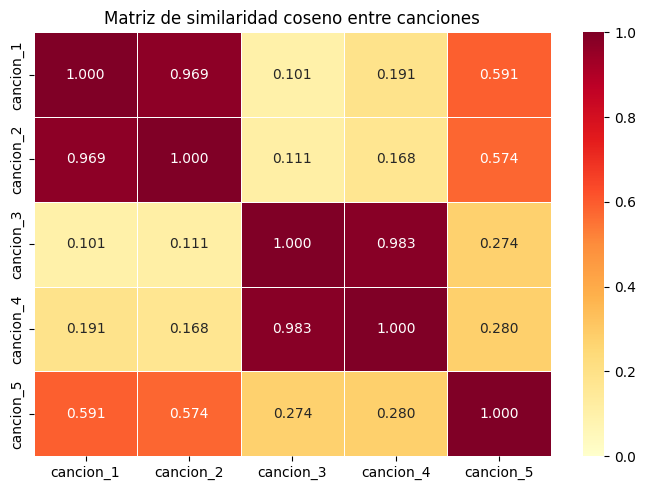

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df_sim, annot=True, fmt='.3f', cmap='YlOrRd',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
)
ax.set_title('Matriz de similaridad coseno entre canciones')
plt.tight_layout()
plt.show()

**Conclusión:** Los pares más similares son `cancion_1` / `cancion_2` (ambas dominadas por "amor" y "vida") y `cancion_3` / `cancion_4` (ambas dominadas por "noche" y "lluvia"). `cancion_5` presenta un perfil distinto, con mayor peso en "sol", lo que la hace menos similar al resto.

### Ejercicio N°4

Una consultora evaluó a un conjunto de candidatos en tres pruebas de selección, todas puntuadas en la misma escala de 0 a 100. Los datos se encuentran en el archivo `candidatos.xlsx`.

1. Explore brevemente el conjunto de datos y realice un análisis exploratorio de la información que el mismo contiene.
2. Se propone utilizar tres variables numéricas para calcular distancias entre candidatos. ¿Considera necesario estandarizarlas antes de calcular distancias? Justifique.
3. Calcule las matrices de distancias euclídeas y Manhattan entre candidatos y visualícelas mediante un gráfico apropiado.
   - Identifique pares de candidatos que sean muy similares o muy diferentes. ¿Observa grupos o patrones?
   - Según ambas métricas: ¿qué candidatos resultan más similares? ¿Qué candidatos resultan más diferentes? ¿Hay pares cuya similitud dependa de la métrica utilizada?

**1. Exploración del conjunto de datos.**

In [19]:
from scipy.spatial.distance import pdist, squareform

candidatos = pd.read_excel('Datasets/candidatos.xlsx')
candidatos

,candidato,prueba_tecnica,prueba_analitica,prueba_comunicacion
0,Ana García,85,78,90
1,Bruno López,82,80,88
2,Carlos Martínez,45,50,42
3,Diana Rodríguez,48,52,45
4,Elena Sánchez,70,65,72
5,Federico Torres,92,88,95
6,Gabriela Díaz,90,85,92
7,Hernán Gómez,30,35,28
8,Isabel Ruiz,68,72,70
9,Javier Herrera,55,60,58


In [20]:
candidatos.describe()

,prueba_tecnica,prueba_analitica,prueba_comunicacion
count,12.000000,12.000000,12.000000
mean,65.250000,64.833333,66.416667
std,21.071847,17.887697,24.062261
min,30.000000,35.000000,28.000000
25%,47.250000,51.500000,44.250000
50%,69.000000,68.500000,71.000000
75%,82.750000,78.500000,88.500000
max,92.000000,88.000000,95.000000


**2. ¿Es necesario estandarizar las variables antes de calcular distancias?**

Las tres variables (`prueba_tecnica`, `prueba_analitica`, `prueba_comunicacion`) están todas medidas en la **misma escala de 0 a 100**. Esto implica que sus rangos son comparables y no existe riesgo de que una variable domine el cálculo de distancias por tener una escala numéricamente mayor. En este caso, **la estandarización no es estrictamente necesaria**.

Si las variables tuviesen escalas heterogéneas (por ejemplo, puntuaciones de 0 a 100 junto a salarios en miles de pesos), la variable de mayor escala dominaría la distancia euclídea, lo que haría imprescindible estandarizar. Aquí ese problema no se presenta.

**3. Matrices de distancias euclídea y Manhattan.**

In [21]:
nombres_cand = candidatos['candidato'].tolist()
X = candidatos[['prueba_tecnica', 'prueba_analitica', 'prueba_comunicacion']].values

dist_eucl = squareform(pdist(X, metric='euclidean'))
dist_manh = squareform(pdist(X, metric='cityblock'))

df_eucl = pd.DataFrame(dist_eucl, index=nombres_cand, columns=nombres_cand)
df_manh = pd.DataFrame(dist_manh, index=nombres_cand, columns=nombres_cand)

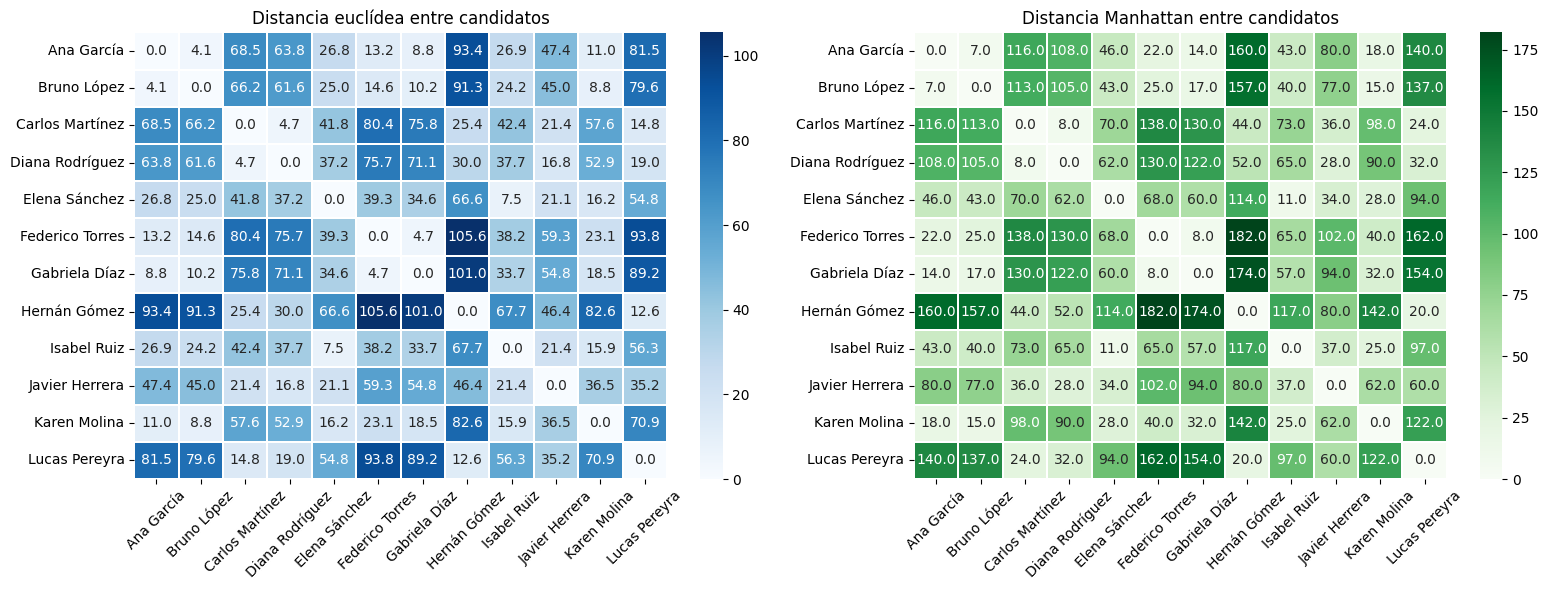

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    df_eucl, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.3, ax=axes[0],
)
axes[0].set_title('Distancia euclídea entre candidatos')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    df_manh, annot=True, fmt='.1f', cmap='Greens',
    linewidths=0.3, ax=axes[1],
)
axes[1].set_title('Distancia Manhattan entre candidatos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Análisis de los resultados:**

- **Candidatos más similares:** Ana García / Bruno López y Federico Torres / Gabriela Díaz presentan las distancias más bajas en ambas métricas, lo que refleja perfiles de puntaje muy cercanos.

- **Candidatos más diferentes:** Hernán Gómez (puntuaciones bajas, ~30) y Federico Torres / Gabriela Díaz (puntuaciones altas, ~90) presentan las distancias máximas.

- **Grupos observados:** Se distinguen tres grupos: candidatos con puntajes altos (Ana, Bruno, Federico, Gabriela, Karen), candidatos con puntajes medios (Elena, Isabel, Javier) y candidatos con puntajes bajos (Carlos, Diana, Hernán, Lucas).

- **Dependencia de la métrica:** Los rankings de similitud son consistentes entre la distancia euclídea y la Manhattan. La distancia Manhattan tiende a ser mayor en valor absoluto que la euclídea (ya que no aplica la raíz cuadrada de la suma de cuadrados), pero los pares más similares y más diferentes son los mismos en ambas métricas.